In [3]:
import yfinance as yf
import pandas as pd
import numpy as np

# -------------------------------------------------------------
# 1. DATA INGESTION
# -------------------------------------------------------------
tickers = [
"AAPL","MSFT","AMZN","GOOGL","META","TSLA","NVDA","JPM","BRK-B","V","MA",
"PEP","KO","WMT","HD","ORCL","CSCO","ADBE","CRM","NFLX","BAC","WFC","XOM",
"CVX","TMO","JNJ","MRK","AMGN"
]

tickers = [t.replace(".", "-") for t in tickers]

prices = yf.download(tickers, start="2010-01-01", auto_adjust=True, progress=False)["Close"]

# Daily returns (no automatic fill)
returns = prices.pct_change(fill_method=None).fillna(0)

# Monthly rebalance dates : give months last date because monthly visuals is normally distributed
rebalance_dates = prices.resample("ME").last().index

# -------------------------------------------------------------
# 2. FACTOR CONSTRUCTION (Cross-Sectional DAILY)
# -------------------------------------------------------------
momentum = prices.pct_change(126, fill_method=None) # we take here 6 month = 252/2 = 126 trend 104 + 9 holiday or quarterly movement of stock # trend
vol = returns.rolling(30).std() * np.sqrt(252)  # risk how fluctutaing it is
value = prices / prices.rolling(252).mean()  # is undervalue or overvalue

# -------------------------------------------------------------
# 3. DATA CLEANING — Winsorization & Z-Scores DAILY
# -------------------------------------------------------------
def cs_winsorize(df, p=0.02): # replacing 2% outlier with less extreme value
    q_low = df.quantile(p, axis=1)
    q_high = df.quantile(1-p, axis=1)
    return df.clip(q_low, q_high, axis=0)

def cs_z(df):
    mean = df.mean(axis=1)
    std = df.std(axis=1).replace(0, np.nan)
    return (df.sub(mean, axis=0)).div(std, axis=0)

momentum = cs_z(cs_winsorize(momentum))
vol = -cs_z(cs_winsorize(vol))
value = cs_z(cs_winsorize(value))

# remove days with NaN across universe
momentum = momentum.dropna(how="all")
vol = vol.dropna(how="all")
value = value.dropna(how="all")

# sync all index ranges
common_index = momentum.index.intersection(vol.index).intersection(value.index)

momentum = momentum.loc[common_index]
vol = vol.loc[common_index]
value = value.loc[common_index]
returns = returns.loc[common_index]

# -------------------------------------------------------------
# 4. FACTOR COMBINATION
# -------------------------------------------------------------
alpha = 0.45 * momentum + 0.30 * vol + 0.25 * value
alpha = alpha.dropna(how="all")

# -------------------------------------------------------------
# 5. RANKING + LONG/SHORT MASKS
# -------------------------------------------------------------
rank = alpha.rank(axis=1, pct=True)
long_mask = rank > 0.80
short_mask = rank < 0.20

# Normalize weights to avoid division-by-zero
long_weights = long_mask.div(long_mask.sum(axis=1), axis=0).fillna(0)
short_weights = short_mask.div(short_mask.sum(axis=1), axis=0).fillna(0)

# -------------------------------------------------------------
# 6. DAILY STRATEGY RETURNS
# -------------------------------------------------------------
long_ret = (returns * long_weights).sum(axis=1)
short_ret = (returns * short_weights).sum(axis=1)

strategy_raw = long_ret - short_ret

# -------------------------------------------------------------
# 7. VOLATILITY TARGETING
# -------------------------------------------------------------
target_vol = 0.15
daily_vol = strategy_raw.rolling(60).std() * np.sqrt(252)
leverage = (target_vol / daily_vol).clip(0, 5).fillna(0)

strategy = strategy_raw * leverage

# -------------------------------------------------------------
# 8. TRANSACTION COSTS
# -------------------------------------------------------------
turnover = leverage.diff().abs().fillna(0)
tcost = turnover * 0.00025

strategy_cost = strategy - tcost

# -------------------------------------------------------------
# 9. PERFORMANCE METRICS
# -------------------------------------------------------------
cumulative = (1 + strategy_cost).cumprod()

years = len(strategy_cost) / 252
cagr = cumulative.iloc[-1]**(1/years) - 1

sharpe = (strategy_cost.mean() * 252) / (strategy_cost.std() * np.sqrt(252))

rolling_max = cumulative.cummax()
drawdown = (cumulative - rolling_max) / rolling_max
max_dd = drawdown.min()

print("\n==== FIXED QUANT REPORT ====")
print(f"CAGR:          {cagr:.4f}")
print(f"Sharpe Ratio:  {sharpe:.4f}")
print(f"Max Drawdown:  {max_dd:.4f}")
print("================================")




==== FIXED QUANT REPORT ====
CAGR:          0.7762
Sharpe Ratio:  3.8126
Max Drawdown:  -0.1116


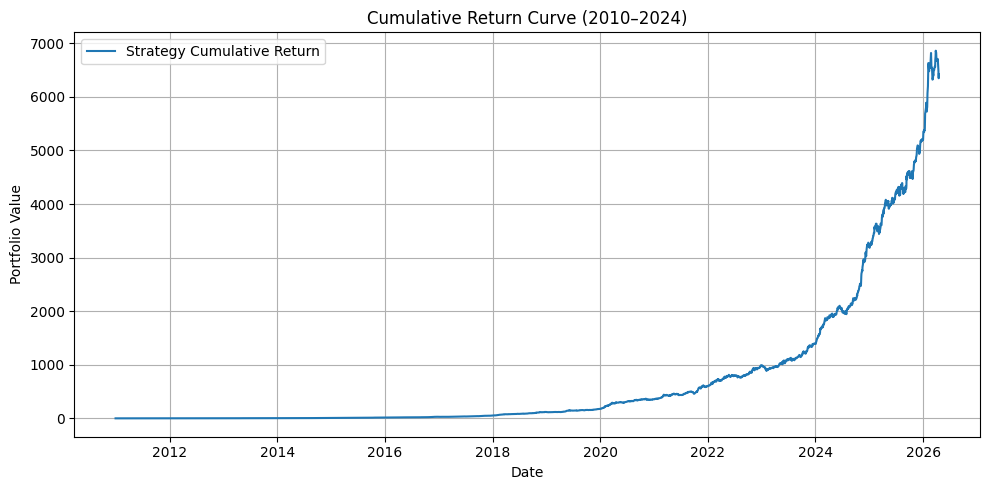

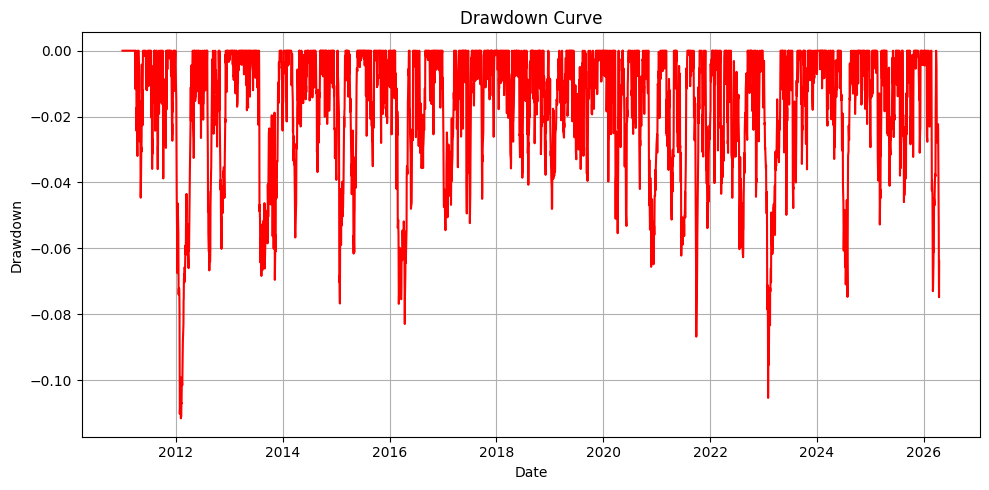

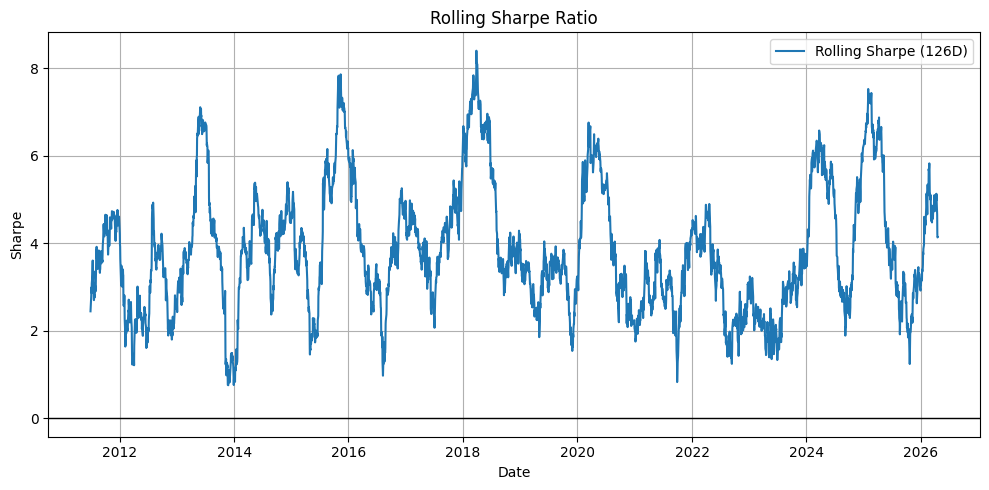

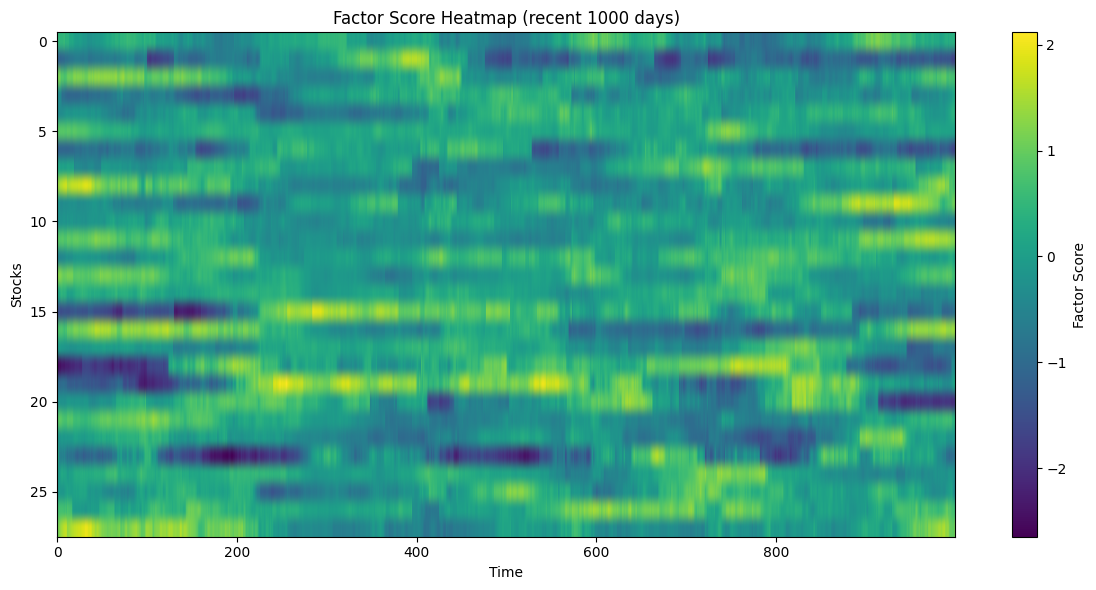

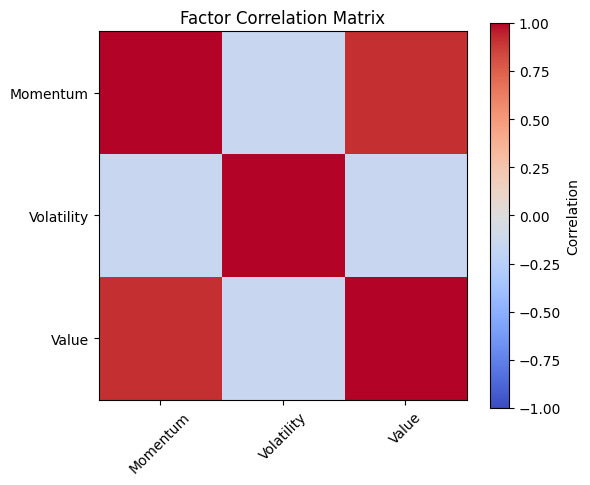

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ============================================================
# 1. CUMULATIVE RETURN CURVE
# ============================================================

cumulative = (1 + strategy_cost).cumprod()

plt.figure(figsize=(10,5))
plt.plot(cumulative, label="Strategy Cumulative Return")
plt.title("Cumulative Return Curve (2010–2024)")
plt.xlabel("Date")
plt.ylabel("Portfolio Value")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


# ============================================================
# 2. DRAWDOWN CURVE
# ============================================================

rolling_max = cumulative.cummax()
drawdown = (cumulative - rolling_max) / rolling_max

plt.figure(figsize=(10,5))
plt.plot(drawdown, color="red")
plt.title("Drawdown Curve")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.grid(True)
plt.tight_layout()
plt.show()


# ============================================================
# 3. ROLLING SHARPE RATIO (126-day, ~6 months)
# ============================================================

rolling_window = 126
rolling_sharpe = (
    strategy_cost.rolling(rolling_window).mean() /
    strategy_cost.rolling(rolling_window).std()
) * np.sqrt(252)

plt.figure(figsize=(10,5))
plt.plot(rolling_sharpe, label="Rolling Sharpe (126D)")
plt.axhline(0, color='black', linewidth=1)
plt.title("Rolling Sharpe Ratio")
plt.xlabel("Date")
plt.ylabel("Sharpe")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


# ============================================================
# 4. FACTOR SCORE HEATMAP
# ============================================================

# Use most recent 1000 days for clean heatmap
alpha_recent = alpha.tail(1000)

plt.figure(figsize=(12,6))
plt.imshow(alpha_recent.T, aspect="auto", cmap="viridis")
plt.colorbar(label="Factor Score")
plt.title("Factor Score Heatmap (recent 1000 days)")
plt.xlabel("Time")
plt.ylabel("Stocks")
plt.tight_layout()
plt.show()


# ============================================================
# 5. FACTOR CORRELATION MATRIX
# ============================================================

factor_df = pd.DataFrame({
    "Momentum": momentum.stack(),
    "Volatility": vol.stack(),
    "Value": value.stack()
}).dropna()

corr_matrix = factor_df.corr()

plt.figure(figsize=(6,5))
plt.imshow(corr_matrix, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr_matrix)), corr_matrix.columns, rotation=45)
plt.yticks(range(len(corr_matrix)), corr_matrix.columns)
plt.title("Factor Correlation Matrix")
plt.tight_layout()
plt.show()
